In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).


In [ ]:
!pip3 install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 17.7 MB/s eta 0:00:00


In [ ]:
import os
from os import listdir
import random
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math
import sys
from glob import glob
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tslearn.datasets import UCR_UEA_datasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler, TimeSeriesScalerMinMax
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy import stats
import keras
from keras import layers, models
from keras.layers import Dense, BatchNormalization, LSTM, Flatten, TimeDistributed, Dropout, GlobalMaxPooling2D, GlobalMaxPooling1D, MaxPooling2D, MaxPooling1D, Conv2D, Conv1D, Input, Reshape, ConvLSTM2D
from tslearn.preprocessing import TimeSeriesScalerMinMax
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

## Load in Data

In [ ]:
# import csv
path = "/content/gdrive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_alt_seg_insole_sensor_df.csv"

interpolated_final_df = pd.read_csv(path)

In [ ]:
# created gait_cycle_id variable
interpolated_final_df['gait_cycle_id'] = interpolated_final_df['participant_id'].astype(str) + '_' + interpolated_final_df['task'].astype(str) + '_' + interpolated_final_df['segment_count'].astype(str)

In [ ]:
# sort value of insole df
interpolated_final_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'], inplace=True)

In [ ]:
# multiply the values by 1000 to try and reduce memory usage

interpolated_final_df['Left_norm'] = (interpolated_final_df['Left_norm'] * 1000).astype(int)
interpolated_final_df['Right_norm'] = (interpolated_final_df['Right_norm'] * 1000).astype(int)
interpolated_final_df['Left_norm_cumulative'] = (interpolated_final_df['Left_norm_cumulative'] * 1000).astype(int)
interpolated_final_df['Right_norm_cumulative'] = (interpolated_final_df['Right_norm_cumulative'] * 1000).astype(int)

In [ ]:
# convert all to int except for sensor_location and gait_cycle_id
interpolated_final_df['participant_id'] = interpolated_final_df['participant_id'].astype(int)
interpolated_final_df['task'] = interpolated_final_df['task'].astype(int)
interpolated_final_df['segment_count'] = interpolated_final_df['segment_count'].astype(int)
interpolated_final_df['time'] = interpolated_final_df['time'].astype(int)
interpolated_final_df['Left_norm'] = interpolated_final_df['Left_norm'].astype(int)
interpolated_final_df['Right_norm'] = interpolated_final_df['Right_norm'].astype(int)
interpolated_final_df['Left_norm_cumulative'] = interpolated_final_df['Left_norm_cumulative'].astype(int)
interpolated_final_df['Right_norm_cumulative'] = interpolated_final_df['Right_norm_cumulative'].astype(int)
interpolated_final_df['walk_mode'] = interpolated_final_df['walk_mode'].astype(int)

In [ ]:
import random

# establish the subject that are in the train/val/test split
number_list = list(interpolated_final_df['participant_id'].unique())

# Choose 3 numbers without replacement
test_three_numbers = random.sample(number_list, 2)
print(test_three_numbers)
train_list = [x for x in number_list if x not in test_three_numbers]

val_three_numbers = random.sample(train_list, 2)
print(val_three_numbers)

train_list = [x for x in train_list if x not in val_three_numbers]
print(train_list)

[22, 1]
[16, 5]
[2, 3, 4, 7, 8, 10, 12, 13, 14, 15, 17, 18, 19, 23, 24, 25]


In [ ]:
# define the variable for each of the train/val/test splits
train = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(train_list)]
val = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(val_three_numbers)]
test = interpolated_final_df.loc[interpolated_final_df['participant_id'].isin(test_three_numbers)]

In [ ]:
# retain only the first instance of gait_cycle_id
train_unique = train.drop_duplicates(subset=['gait_cycle_id'], keep='first')

In [ ]:
# Oversample smaller classes to balance the dataset
min_samples = int(train_unique['walk_mode'].value_counts().min())

In [ ]:
# Downsample to balance classes
balanced_gait_cycles = (
    train_unique.groupby('walk_mode')
    .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))
    .reset_index(drop=True)
)

<ipython-input-17-e6181ac3816b>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min_samples, replace=False, random_state=42))


In [ ]:
print(balanced_gait_cycles['walk_mode'].value_counts())

walk_mode
0    3127
1    3127
2    3127
3    3127
4    3127
Name: count, dtype: int64


In [ ]:
filtered_interpolated_final_df = pd.merge(
    train,
    balanced_gait_cycles[['gait_cycle_id']],
    on='gait_cycle_id',
    how='inner'
)

In [ ]:
filtered_interpolated_final_df['participant_id'].unique()

array([ 2,  3,  4,  7,  8, 10, 12, 13, 14, 15, 17, 18, 19, 23, 24, 25])

In [ ]:
train = filtered_interpolated_final_df.copy()

In [ ]:
total_num = 0
for p in  train['participant_id'].unique():
    participant_1 = train[train['participant_id'] == p]
    pant_num = participant_1['segment_count'].nunique()
    total_num += pant_num
print(total_num)

13602


In [ ]:
train['walk_mode'].value_counts()

,count
walk_mode,
4,2001280
2,2001280
3,2001280
0,2001280
1,2001280


In [ ]:
le = LabelEncoder()

# exchange strings for numerical labels
train['gait_cycle_id'] = le.fit_transform(train['gait_cycle_id'])
train['sensor_location'] = le.fit_transform(train['sensor_location'])
train['task'] = le.fit_transform(train['task'])
train['walk_mode'] = le.fit_transform(train['walk_mode'])

val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
val['sensor_location'] = le.fit_transform(val['sensor_location'])
val['task'] = le.fit_transform(val['task'])
val['walk_mode'] = le.fit_transform(val['walk_mode'])

test['gait_cycle_id'] = le.fit_transform(test['gait_cycle_id'])
test['sensor_location'] = le.fit_transform(test['sensor_location'])
test['task'] = le.fit_transform(test['task'])
test['walk_mode'] = le.fit_transform(test['walk_mode'])

<ipython-input-27-b990848ca3d9>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['gait_cycle_id'] = le.fit_transform(val['gait_cycle_id'])
<ipython-input-27-b990848ca3d9>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val['sensor_location'] = le.fit_transform(val['sensor_location'])
<ipython-input-27-b990848ca3d9>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

In [ ]:
train['walk_mode'].value_counts()

,count
walk_mode,
4,2001280
2,2001280
3,2001280
0,2001280
1,2001280


In [ ]:
def preprocess_data(df):
    all_data_x = []
    all_labels_y = []

    for gait_cycle_id, group_data in df.groupby('gait_cycle_id'):
        # Sort by time to ensure consistent order
        group_data = group_data.sort_values(by='time')

        # Prepare a 2D array to hold data for the current gait cycle (80, 18)
        segment_data = []

        # Group by sensor location and extract data in the desired order
        sensor_data_dict = {}
        for sensor_location, sensor_data in group_data.groupby('sensor_location'):
            sensor_array = sensor_data[['Left_norm', 'Right_norm']].values
            sensor_data_dict[sensor_location] = sensor_array

        # Ensure all sensor data has the same time length (80)
        for sensor_location in sorted(sensor_data_dict.keys()):
            sensor_array = sensor_data_dict[sensor_location]
            if len(sensor_array) < 80:
                # Pad with zeros if shorter
                padding = np.zeros((80 - len(sensor_array), 2))
                sensor_array = np.vstack([sensor_array, padding])
            elif len(sensor_array) > 80:
                # Truncate if longer
                sensor_array = sensor_array[:80]

            segment_data.append(sensor_array)

        # Add cumulative data
        cumulative_data = group_data[['Left_norm_cumulative', 'Right_norm_cumulative']].values[:80]
        if len(cumulative_data) < 80:
            padding = np.zeros((80 - len(cumulative_data), 2))
            cumulative_data = np.vstack([cumulative_data, padding])

        segment_data.append(cumulative_data)

        # Combine all sensor data into the final 2D array for the segment (80, 18)
        segment_data = np.hstack(segment_data)
        all_data_x.append(segment_data)

        # Extract labels for the gait cycle
        walk_mode_data = group_data['walk_mode'].values[:80]
        if len(walk_mode_data) < 80:
            walk_mode_data = np.pad(walk_mode_data, (0, 80 - len(walk_mode_data)), constant_values=-1)  # Use -1 for padding

        all_labels_y.append(walk_mode_data)

    # Convert lists to NumPy arrays
    all_data_x = np.array(all_data_x)  # Shape: [x, 80, 18]
    all_labels_y = np.array(all_labels_y)  # Shape: [x, 80]

    return all_data_x, all_labels_y


In [ ]:
train_all_data_x, train_all_labels_y = preprocess_data(train)

In [ ]:
val_all_data_x, val_all_labels_y = preprocess_data(val)

In [ ]:
test_all_data_x, test_all_labels_y = preprocess_data(test)

In [ ]:
train_all_labels_y = np.swapaxes(train_all_labels_y, 0, 1)
train_all_labels_y = train_all_labels_y[0]

val_all_labels_y = np.swapaxes(val_all_labels_y, 0, 1)
val_all_labels_y = val_all_labels_y[0]

test_all_labels_y = np.swapaxes(test_all_labels_y, 0, 1)
test_all_labels_y = test_all_labels_y[0]

In [ ]:
from keras.utils import to_categorical

# Assuming the labels are already numeric
train_all_labels_y = to_categorical(train_all_labels_y)
val_all_labels_y = to_categorical(val_all_labels_y)
test_all_labels_y = to_categorical(test_all_labels_y)

In [ ]:
train_all_labels_y.shape, train_all_labels_y[0]

((15635, 5), array([0., 0., 1., 0., 0.]))

In [ ]:
train_all_data_x.shape, train_all_labels_y.shape, val_all_data_x.shape, val_all_labels_y.shape, test_all_data_x.shape, test_all_labels_y.shape

((15635, 80, 18),
 (15635, 5),
 (8559, 80, 18),
 (8559, 5),
 (8349, 80, 18),
 (8349, 5))

In [ ]:
train_X = train_all_data_x
train_Y = train_all_labels_y

val_X = val_all_data_x
val_Y = val_all_labels_y

test_X = test_all_data_x
test_Y = test_all_labels_y

In [ ]:
n_obs, n_timesteps, n_features, n_classes = train_X.shape[0], train_X.shape[1], train_X.shape[2], train_Y.shape[1]

In [ ]:
n_obs, n_timesteps, n_features, n_classes

(15635, 80, 18, 5)

## hyperparameter tuning

In [ ]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 8.7 MB/s eta 0:00:00


In [ ]:
# Clears the session for TensorFlow
tf.keras.backend.clear_session()

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, LSTM, Attention, Concatenate, Dense, Bidirectional, BatchNormalization, MaxPooling1D, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from kerastuner.tuners import Hyperband

# Function to build model for Keras Hyperparameter tuning
def build_model(hp):
    input_shape = (80, 18)
    inputs = Input(shape=input_shape)

    # CNN layer
    cnn_out = BatchNormalization()(inputs)
    cnn_out = Conv1D(
            filters=hp.Int('filters', min_value=32, max_value=128, step=32),
            kernel_size=hp.Choice('kernel_size', values=[3, 5]),
            activation='relu')(cnn_out)
    cnn_out = MaxPooling1D(pool_size=2)(cnn_out)
    cnn_out = Dropout(hp.Float('cnn_dropout', 0.3, 0.5, step=0.05))(cnn_out)


    # Bidirectional LSTM layer
    lstm_out = Bidirectional(LSTM(
        units=hp.Int('lstm_units', min_value=64, max_value=256, step=64),
        dropout=hp.Float('lstm_dropout', 0.3, 0.5, step=0.05),
        recurrent_dropout=hp.Float('recurrent_dropout', 0.3, 0.5, step=0.05),
        return_sequences=True  # Return sequences for Attention layer
    ))(cnn_out)

    # Attention layer
    attention = Attention()([lstm_out, lstm_out])
    merged_output = Concatenate(axis=-1)([lstm_out, attention])

    # MLP layer
    mlp_out = Flatten()(merged_output)
    mlp_out = Dense(
        units=hp.Int('dense1_units', min_value=64, max_value=256, step=64),
        activation='relu'
    )(mlp_out)
    mlp_out = Dense(
        units=hp.Int('dense2_units', min_value=32, max_value=128, step=32),
        activation='relu'
    )(mlp_out)

    # Output layer with softmax activation for multi-class classification
    output_layer = Dense(n_classes, activation='softmax')(mlp_out)

    # Compile model
    model = tf.keras.models.Model(inputs=inputs, outputs=output_layer)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Define Keras Tuner
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    factor=3,
    directory='keras_tuner_dir',
    project_name='cnn_lstm_tuning'
)

# Run the search
tuner.search(train_X, train_Y, validation_data=(val_X, val_Y), epochs=20, callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)


Trial 30 Complete [00h 04m 41s]
val_accuracy: 0.5085874795913696

Best val_accuracy So Far: 0.7263699173927307
Total elapsed time: 02h 56m 27s


## Train Model

In [ ]:
# print the best model
best_model.summary()

In [ ]:
# Build the model with the best hp
model = build_model(best_hps)

# Fit with the entire dataset
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
history = model.fit(train_X, train_Y, epochs=100, batch_size=128, callbacks=[callback], validation_data=(val_X, val_Y))

Epoch 1/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 56s 384ms/step - accuracy: 0.3428 - loss: 7.4171 - val_accuracy: 0.7378 - val_loss: 0.8083
Epoch 2/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 374ms/step - accuracy: 0.5556 - loss: 0.9429 - val_accuracy: 0.4589 - val_loss: 1.0992
Epoch 3/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 371ms/step - accuracy: 0.6752 - loss: 0.7436 - val_accuracy: 0.2965 - val_loss: 2.6429
Epoch 4/100
123/123 ━━━━━━━━━━━━━━━━━━━━ 46s 372ms/step - accuracy: 0.7104 - loss: 0.6826 - val_accuracy: 0.5988 - val_loss: 0.9461


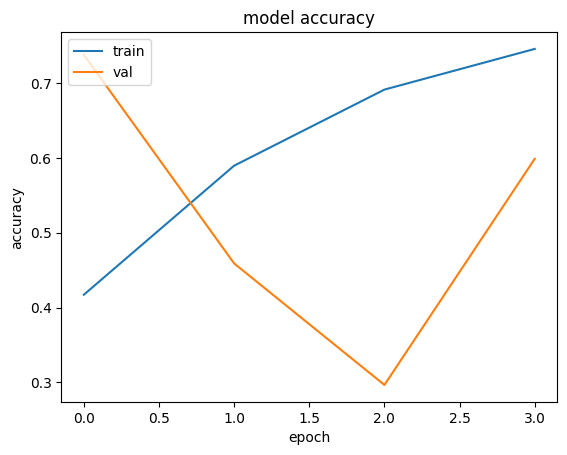

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

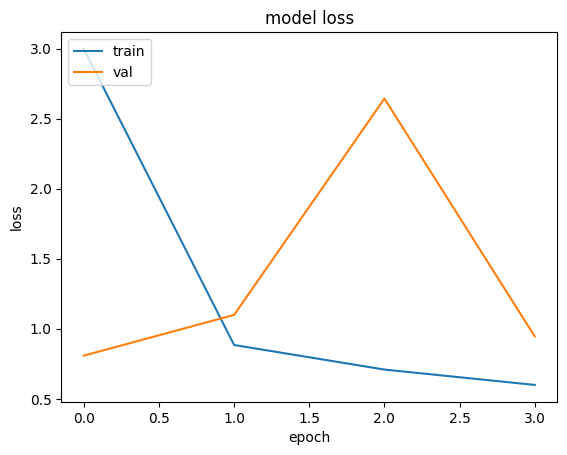

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_X, test_Y)

261/261 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.5428 - loss: 0.8525


In [ ]:
# Check shapes of test data before evaluation
print("Test X shape:", test_X[0].shape)
print("Test Y shape:", test_Y[0].shape)

Test X shape: (80, 18)
Test Y shape: (5,)


In [ ]:
#predictions
predictions = model.predict(test_X)

261/261 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step


In [ ]:
# Convert predictions to class labels
predicted_classes = tf.argmax(predictions, axis=-1)

# Convert true labels to class labels (if needed)
true_classes = tf.argmax(test_Y, axis=-1)

# Calculate accuracy
accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted_classes, true_classes), tf.float32))
print(f"Test accuracy: {accuracy.numpy() * 100:.2f}%")

# Display predicted and true classes for further inspection
print("Predicted classes:", predicted_classes.numpy())
print("True classes:", true_classes.numpy())

Test accuracy: 51.84%
Predicted classes: [1 3 3 ... 1 1 1]
True classes: [4 2 3 ... 4 4 4]


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score

# Convert predictions and true labels to NumPy arrays
# The variables are already numpy arrays, so no conversion is needed.
predicted_classes_np = predicted_classes
true_classes_np = true_classes

# Generate a classification report (includes precision, recall, F1-score for each class)
report = classification_report(true_classes_np, predicted_classes_np, digits=4)
print("Classification Report:\n", report)

# Compute confusion matrix
conf_matrix = confusion_matrix(true_classes_np, predicted_classes_np)
print("Confusion Matrix:\n", conf_matrix)

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")

# Custom calculation for specificity per class
specificities = []
for i in range(conf_matrix.shape[0]):
    tn = conf_matrix.sum() - (conf_matrix[i, :].sum() + conf_matrix[:, i].sum() - conf_matrix[i, i])
    fp = conf_matrix[:, i].sum() - conf_matrix[i, i]
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificities.append(specificity)

print(f"Specificities (per class): {specificities}")

Classification Report:
               precision    recall  f1-score   support

           0     0.9636    0.5678    0.7146      1585
           1     0.2800    0.9750    0.4351      1159
           2     0.8843    0.3156    0.4652       339
           3     0.6265    0.9341    0.7500       607
           4     0.6899    0.3486    0.4631      4659

    accuracy                         0.5184      8349
   macro avg     0.6889    0.6282    0.5656      8349
weighted avg     0.6882    0.5184    0.5279      8349

Confusion Matrix:
 [[ 900    5    0    0  680]
 [   0 1130    0    1   28]
 [   8    0  107  220    4]
 [   0   22    0  567   18]
 [  26 2878   14  117 1624]]
F1-Scores (per class): [0.56782334 0.97497843 0.31563422 0.93410214 0.34857266]
Specificities (per class): [0.9949733885274985, 0.5959666203059806, 0.9982521847690387, 0.9563420304830793, 0.8021680216802168]


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score # Import the f1_score function
from sklearn.metrics import precision_recall_fscore_support

# Calculate F1-score and sensitivity (recall) per class
f1_scores = recall_score(true_classes_np, predicted_classes_np, average=None)
print(f"F1-Scores (per class): {f1_scores}")
f1 = f1_score(true_classes_np, predicted_classes_np, average='weighted')
# overall F1 score average
overall_F1 = round(math.fsum(f1_scores) / len(f1_scores),2)
print(f"Overall F1 Score: {overall_F1}")


F1-Scores (per class): [0.56782334 0.97497843 0.31563422 0.93410214 0.34857266]
Overall F1 Score: 0.63


In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# print the class and overall sensitivity and specificity
res = []
for l in [0,1,2,3,4]:
     prec,recall,_,_ = precision_recall_fscore_support(np.array(true_classes_np)==l,
                                                  np.array(predicted_classes_np)==l,
                                                  pos_label=True,average=None)
     res.append([l,recall[0],recall[1]])

sens_spes = pd.DataFrame(res,columns = ['class','specificity','sensitivity'])
print(sens_spes)

overall_specificity = sens_spes['specificity'].mean()
overall_sensitivity = sens_spes['sensitivity'].mean()
print(f"Overall specificity: {round(overall_specificity,2)}")
print(f"Overall sensitivity: {round(overall_sensitivity, 2)}")

   class  specificity  sensitivity
0      0     0.994973     0.567823
1      1     0.595967     0.974978
2      2     0.998252     0.315634
3      3     0.956342     0.934102
4      4     0.802168     0.348573
Overall specificity: 0.87
Overall sensitivity: 0.63


## Confusion Matrix

In [ ]:
# Compute the confusion matrix
result = confusion_matrix(true_classes, predicted_classes)

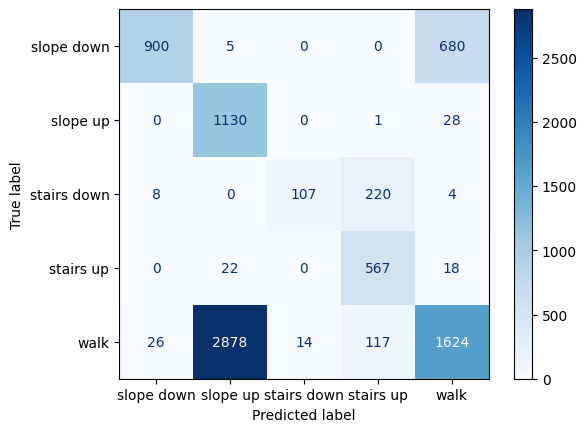

In [ ]:
# plot the confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = result, display_labels = ['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'])

cm_display.plot(cmap=plt.cm.Blues)
plt.show()

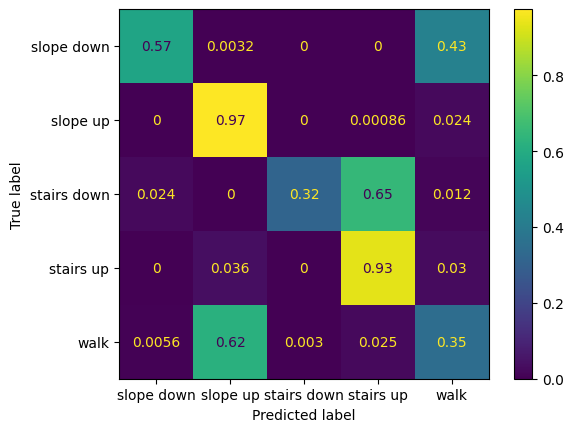

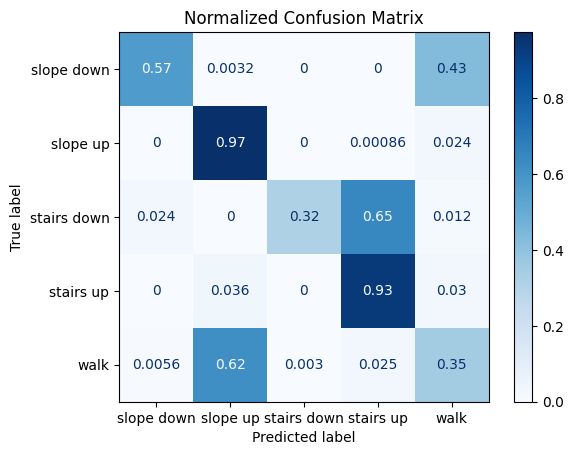

In [ ]:
# Create the normalized confusion matrix display using the from_predictions method
cm_display = ConfusionMatrixDisplay.from_predictions(
    true_classes,
    predicted_classes,
    display_labels=['slope down', 'slope up', 'stairs down', 'stairs up', 'walk'],
    normalize='true'  # Normalize by the true labels
)

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Normalized Confusion Matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()